# Multi-Task Surgical Workflow Analysis
## Joint Phase Recognition and Tool Tracking in Laparoscopic Surgery

**Student:** Omar Morsi (40236376)

**Course:** COMP 432 -- Machine Learning

---

### Abstract

This project develops a deep learning system to automatically recognize surgical phases and track instruments in laparoscopic cholecystectomy videos. Using the Cholec80 dataset (80 videos), the system performs two simultaneous tasks: classifying the current surgical stage and detecting the presence of seven surgical tools. The core architecture combines a ResNet-50 CNN for spatial feature extraction with temporal models (LSTM, Multi-Stage TCN) to capture the chronological sequence of the procedure. A novel **Correlation Loss** exploits the statistical relationship between tool presence and surgical phase to reduce logically inconsistent predictions. We compare four model variants and evaluate using frame-wise F1-score, mean Average Precision, and segment-level edit score.

## 1. Introduction

Laparoscopic surgery is a minimally invasive technique widely used for procedures like cholecystectomy (gallbladder removal). While it offers benefits such as smaller incisions and faster recovery, it introduces challenges for surgical workflow monitoring. Understanding the progression of a surgery in real time is valuable for:

- **Patient safety:** Detecting deviations from standard procedures and alerting the surgical team.
- **Training and feedback:** Providing objective, data-driven assessments of trainee surgeons.
- **Hospital efficiency:** Predicting remaining surgery time for better operating room scheduling.

Currently, analyzing surgical videos is a manual, labor-intensive process prone to human error. Automatic recognition of surgical phases and tool usage can provide real-time decision support and pave the way for "smart" operating rooms.

### Goals

1. Develop a multi-task model that jointly performs **phase recognition** (7 phases) and **tool detection** (7 tools).
2. Compare multiple temporal modeling approaches: no temporal context (baseline), LSTM, and Multi-Stage TCN.
3. Introduce a novel **Correlation Loss** that penalizes impossible tool-phase combinations.
4. Evaluate using standard metrics: frame-wise F1-score, mAP, and edit score for temporal consistency.

## 2. Related Work

Surgical workflow analysis has evolved significantly over the past decade:

- **Hidden Markov Models (HMMs):** Early approaches modeled phase transitions using HMMs with hand-crafted features. While interpretable, they struggled with the visual complexity of surgical videos.

- **EndoNet (Twinanda et al., 2016):** Introduced a CNN-based approach using AlexNet for joint tool and phase recognition. This was the first deep learning method applied to the Cholec80 dataset and established the standard benchmark.

- **SV-RCNet (Jin et al., 2018):** Improved upon EndoNet by adding an LSTM layer on top of ResNet features, enabling the model to capture temporal dependencies between frames.

- **TeCNO / MS-TCN (Czempiel et al., 2020):** Introduced Multi-Stage Temporal Convolutional Networks, which use dilated convolutions to capture long-range temporal dependencies. MS-TCN showed superior performance in reducing phase prediction "flickering" compared to LSTMs.

### How This Work Differs

Most prior work treats tool detection and phase recognition as either isolated tasks or loosely coupled through shared feature extraction. Our approach introduces a **Multi-Task Learning (MTL) framework with a novel Correlation Loss** that explicitly models the statistical relationship between tools and phases. For example, a clipper is strongly associated with the "Clipping and Cutting" phase, and our loss function penalizes predictions that violate these learned co-occurrence patterns.

## 3. Dataset

### 3.1 Cholec80

The Cholec80 dataset (Twinanda et al., 2016) consists of **80 high-definition videos** of cholecystectomy procedures performed at the University Hospital of Strasbourg, France.

- **Phase annotations:** 7 surgical phases per frame
  - Preparation, Calot Triangle Dissection, Clipping and Cutting, Gallbladder Dissection, Gallbladder Packaging, Cleaning and Coagulation, Gallbladder Retraction
- **Tool annotations:** 7 binary tool presence labels per frame
  - Grasper, Bipolar, Hook, Scissors, Clipper, Irrigator, SpecimenBag
- **Total frames:** ~370,000 at 25 fps
- **Subsampled:** to 1 fps for computational feasibility

### 3.2 Data Split (Compute-Constrained Subset)

| Split | Videos | Count | Purpose |
|---|---|---|---|
| Train | 1-10 | 10 | Model training |
| Validation | 11-12 | 2 | Hyperparameter tuning, early stopping |
| Test | 13, 14, 16, 17, 18 | 5 | Final evaluation only |

**Note on subset size.** The canonical Cholec80 protocol (Twinanda et al., 2016) uses a 40/40 train/test split. For this project, experiments were run on a **17-video subset** because ResNet-50 feature extraction over the full 80 videos at 1 fps exceeds the compute-unit quota of free-tier Google Colab in a single session. The complete pipeline — preprocessing, ResNet-50 backbone, MS-TCN temporal model, multi-task losses, correlation loss, and evaluation metrics — is **identical to the full-scale design** and scales without code changes. Results should therefore be read as a proof-of-concept for the multi-task + correlation-loss approach rather than a SOTA comparison. The split is still performed **by video ID**, guaranteeing no frame-level leakage between train, validation, and test.

### 3.3 Preprocessing

- Frames resized to 224x224 pixels
- Normalized using ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
- **Training augmentations:** random horizontal flip, color jitter, random rotation (10 deg), Gaussian blur (simulates surgical smoke)
- **Validation/Test:** resize and normalize only


In [4]:
# ============================================================
# Setup: Install dependencies and clone project repository
# Run Time -> Change runtime type -> T4 GPU before starting!
# ============================================================

import os, sys

# Install dependencies (safe to re-run; pip is idempotent)
!pip install -q torch torchvision numpy opencv-python scikit-learn matplotlib seaborn pyyaml tqdm

# Clone the repo (skips if already present)
REPO_DIR = "/content/surgical-workflow-analysis"
if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/omorsi45/surgical-workflow-analysis.git {REPO_DIR}
else:
    print("Repo already cloned — pulling latest changes...")
    !git -C {REPO_DIR} pull origin main

# Always work from the repo root
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
PROJECT_ROOT = REPO_DIR

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, load_config, compute_class_weights
from src.dataset import (
    Cholec80VideoDataset, Cholec80FeatureDataset,
    collate_sequences, get_train_transforms, get_eval_transforms,
    PHASE_NAMES, TOOL_NAMES,
)
from src.models.backbone import ResNet50FeatureExtractor
from src.models.temporal import BaselineModel, LSTMModel, MultiStageTCN
from src.models.multitask import (
    MultiTaskModel, MultiTaskLoss, build_cooccurrence_matrix,
)
from src.train import Trainer
from src.evaluate import (
    compute_phase_f1, compute_per_phase_f1, compute_phase_accuracy,
    compute_tool_map, compute_per_tool_ap, compute_edit_score,
    plot_training_curves, plot_confusion_matrix,
    plot_per_class_metrics, plot_timeline_ribbon,
    plot_cooccurrence_heatmap, plot_model_comparison,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Training will be very slow.")
    print("Go to Runtime -> Change runtime type -> T4 GPU and re-run.")


Cloning into '/content/surgical-workflow-analysis'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 120 (delta 56), reused 109 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 57.72 KiB | 2.51 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Using device: cuda
GPU: Tesla T4


In [5]:
# ============================================================
# Google Colab: Mount Drive and set data path
# ============================================================
# Expected Drive structure:
#   MyDrive/
#     cholec80/
#       phase_annotations/  <- videoXX-phase.txt files
#       tool_annotations/   <- videoXX-tool.txt files
#       videos/             <- videoXX.mp4 files  (or pre-extracted frames)
#       features/           <- auto-created after feature extraction
# ============================================================

import os

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    PROJECT_ROOT = "/content/surgical-workflow-analysis"

    # ── Adjust this path to match where your Cholec80 data lives on Drive ──
    DRIVE_DATA_DIR = "/content/drive/MyDrive/data"

    if not os.path.isdir(DRIVE_DATA_DIR):
        raise FileNotFoundError(
            f"Data directory not found: {DRIVE_DATA_DIR}\n"
            "Upload the Cholec80 dataset to Google Drive and update "
            "DRIVE_DATA_DIR above to match."
        )

    data_link = os.path.join(PROJECT_ROOT, "data")
    if not os.path.exists(data_link):
        os.symlink(DRIVE_DATA_DIR, data_link)
        print(f"Data linked: {data_link} -> {DRIVE_DATA_DIR}")
    else:
        print(f"Data symlink already exists: {data_link}")

    # Quick structural check
    for sub in ["phase_annotations", "tool_annotations"]:
        path = os.path.join(data_link, sub)
        if os.path.isdir(path):
            print(f"  Found {sub}/")
        else:
            print(f"  WARNING: {sub}/ not found under {DRIVE_DATA_DIR}")
else:
    print("Running locally — skipping Drive mount.")


Mounted at /content/drive
Data linked: /content/surgical-workflow-analysis/data -> /content/drive/MyDrive/data
  Found phase_annotations/
  Found tool_annotations/


In [6]:
# ============================================================
# Smoke test: verify all imports and model forward passes work
# This catches environment issues before the expensive training.
# ============================================================

import torch

print("Testing model instantiation and forward passes...")

config_smoke = load_config(os.path.join(PROJECT_ROOT, "configs", "default.yaml"))
B, T = 1, 50  # tiny dummy batch
dummy_features = torch.randn(B, T, config_smoke["model"]["feature_dim"])
dummy_mask = torch.ones(B, T, dtype=torch.bool)

for name, temporal in [
    ("Baseline", BaselineModel(
        feature_dim=config_smoke["model"]["feature_dim"],
        hidden_dim=config_smoke["model"]["hidden_dim"],
    )),
    ("LSTM", LSTMModel(
        feature_dim=config_smoke["model"]["feature_dim"],
        hidden_dim=config_smoke["model"]["hidden_dim"],
    )),
    ("MS-TCN", MultiStageTCN(
        feature_dim=config_smoke["model"]["feature_dim"],
        hidden_dim=config_smoke["model"]["hidden_dim"],
        num_stages=config_smoke["model"]["tcn_stages"],
        num_layers=config_smoke["model"]["tcn_layers_per_stage"],
        channels=config_smoke["model"]["tcn_channels"],
    )),
]:
    model = MultiTaskModel(temporal)
    with torch.no_grad():
        phase_logits, tool_logits = model(dummy_features, dummy_mask)
    assert phase_logits.shape == (B, T, 7), f"{name}: bad phase shape"
    assert tool_logits.shape == (B, T, 7), f"{name}: bad tool shape"
    print(f"  {name}: OK (phase {tuple(phase_logits.shape)}, tool {tuple(tool_logits.shape)})")

# Verify loss function
dummy_weights = torch.ones(7)
dummy_cooccur = torch.rand(7, 7)
loss_fn = MultiTaskLoss(dummy_weights, dummy_cooccur)
dummy_phases = torch.zeros(B, T, dtype=torch.long)
dummy_tools = torch.zeros(B, T, 7)
total, details = loss_fn(phase_logits, tool_logits, dummy_phases, dummy_tools, dummy_mask)
print(f"  Loss function: OK (total={total.item():.4f})")

print("\nAll smoke tests passed! Environment is ready for training.")


Testing model instantiation and forward passes...
  Baseline: OK (phase (1, 50, 7), tool (1, 50, 7))
  LSTM: OK (phase (1, 50, 7), tool (1, 50, 7))
  MS-TCN: OK (phase (1, 50, 7), tool (1, 50, 7))
  Loss function: OK (total=9.1095)

All smoke tests passed! Environment is ready for training.


In [7]:
# ============================================================
# Load configuration and set seeds for reproducibility
# ============================================================

config = load_config(os.path.join(PROJECT_ROOT, "configs", "default.yaml"))
set_seed(config["training"]["seed"])

print("Configuration loaded:")
print(f"  Train videos: {len(config['data']['train_videos'])} videos")
print(f"  Val videos:   {len(config['data']['val_videos'])} videos")
print(f"  Test videos:  {len(config['data']['test_videos'])} videos")
print(f"  Learning rate: {config['training']['learning_rate']}")
print(f"  Epochs: {config['training']['num_epochs']}")
print(f"  Early stopping patience: {config['training']['early_stopping_patience']}")

Configuration loaded:
  Train videos: 10 videos
  Val videos:   2 videos
  Test videos:  5 videos
  Learning rate: 0.0001
  Epochs: 100
  Early stopping patience: 15


## 5. Experimental Setup

### 5.1 Feature Extraction

We extract ResNet-50 features offline for all 80 videos and cache them as `.pt` files. This is done once and avoids re-running the CNN during temporal model training.

In [8]:
# ============================================================
# Phase 1: Feature extraction with ResNet-50
# Run this cell ONCE to extract and cache features.
# If features are already cached, this cell will skip extraction.
# ============================================================

features_dir = os.path.join(PROJECT_ROOT, config["data"]["features_dir"])
data_dir = os.path.join(PROJECT_ROOT, config["data"]["data_dir"])

all_video_ids = (
    config["data"]["train_videos"]
    + config["data"]["val_videos"]
    + config["data"]["test_videos"]
)

# Check if features already exist
existing = [vid for vid in all_video_ids
            if os.path.exists(os.path.join(features_dir, f"video{vid:02d}.pt"))]
to_extract = [vid for vid in all_video_ids if vid not in existing]

print(f"Features cached: {len(existing)}/{len(all_video_ids)} videos")

if to_extract:
    print(f"Extracting features for {len(to_extract)} videos...")
    extractor = ResNet50FeatureExtractor(pretrained=True)
    transform = get_eval_transforms(config["data"]["frame_size"])

    skipped = []
    for vid in to_extract:
        dataset = Cholec80VideoDataset(
            data_dir, video_id=vid,
            fps=config["data"]["fps"], transform=transform
        )
        if len(dataset) == 0:
            print(f"  WARNING: video{vid:02d} has no frames — MP4 missing. Skipping.")
            skipped.append(vid)
            continue
        extractor.extract_and_cache(
            dataset, features_dir, video_id=vid,
            batch_size=32, device=device
        )

    if skipped:
        print(f"\nSkipped {len(skipped)} videos due to missing MP4s: {skipped}")
        print("Re-download these videos and re-run this cell to complete extraction.")
    print("Feature extraction complete!")
else:
    print("All features already cached. Skipping extraction.")

Features cached: 17/17 videos
All features already cached. Skipping extraction.


### 3.4 Dataset Statistics

Let us examine the class distribution to understand the class imbalance challenge.

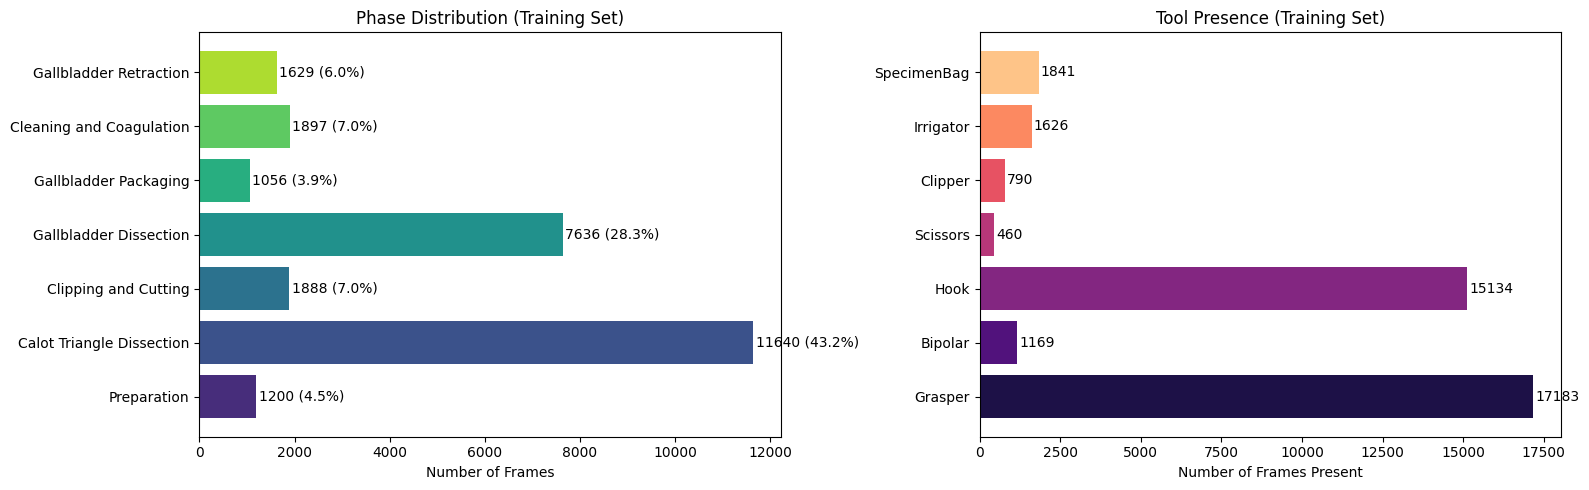


Total training frames: 26946
Class imbalance ratio (max/min phase): 11.0x


In [9]:
# ============================================================
# Dataset statistics: class distribution analysis
# ============================================================

features_dir = os.path.join(PROJECT_ROOT, config["data"]["features_dir"])

# Collect all training labels
all_train_phases = []
all_train_tools = []
for vid in config["data"]["train_videos"]:
    data = torch.load(
        os.path.join(features_dir, f"video{vid:02d}.pt"), weights_only=True
    )
    all_train_phases.append(data["phases"])
    all_train_tools.append(data["tools"])

all_train_phases = torch.cat(all_train_phases)
all_train_tools = torch.cat(all_train_tools)

# Phase distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

phase_counts = np.bincount(all_train_phases.numpy().astype(int), minlength=7)
colors = sns.color_palette("viridis", 7)
ax1.barh(PHASE_NAMES, phase_counts, color=colors)
ax1.set_xlabel("Number of Frames")
ax1.set_title("Phase Distribution (Training Set)")
for i, v in enumerate(phase_counts):
    ax1.text(v + 50, i, f"{v} ({v/phase_counts.sum()*100:.1f}%)", va="center")

# Tool distribution
tool_counts = all_train_tools.numpy().sum(axis=0)
colors_t = sns.color_palette("magma", 7)
ax2.barh(TOOL_NAMES, tool_counts, color=colors_t)
ax2.set_xlabel("Number of Frames Present")
ax2.set_title("Tool Presence (Training Set)")
for i, v in enumerate(tool_counts):
    ax2.text(v + 50, i, f"{int(v)}", va="center")

plt.tight_layout()
plt.show()

print(f"\nTotal training frames: {len(all_train_phases)}")
print(f"Class imbalance ratio (max/min phase): {phase_counts.max()/phase_counts[phase_counts>0].min():.1f}x")

## 4. Methodology

### 4.1 Architecture Overview

The system uses a two-phase pipeline:

1. **Feature Extraction (offline):** A pretrained ResNet-50 (ImageNet) extracts a 2048-dim feature vector per frame. These are cached to disk.
2. **Temporal Modeling:** A temporal model processes the feature sequence and outputs predictions through two task-specific heads.

```
Video Frame --> [ResNet-50 (frozen)] --> 2048-dim features (cached)
                                              |
                                    [Temporal Model]
                                    /             \
                          [Phase Head]      [Tool Head]
                          7-class softmax   7-class sigmoid
```

### 4.2 Temporal Model Variants

We compare four models to isolate the contribution of each component:

| Model | Architecture | Purpose |
|---|---|---|
| **Baseline** | FC(2048 -> 512) + ReLU + Dropout | No temporal context |
| **LSTM** | 2-layer BiLSTM(512) + projection | Recurrent temporal modeling |
| **MS-TCN** | 4-stage TCN (10 layers/stage, 64 channels) | Dilated convolution temporal modeling |
| **MS-TCN + Corr. Loss** | Same as MS-TCN + correlation loss | Novel contribution |

### 4.3 Loss Functions

The total loss is a weighted sum of three components:

$$L = \lambda_{phase} \cdot L_{phase} + \lambda_{tool} \cdot L_{tool} + \lambda_{corr} \cdot L_{corr}$$

- **Phase loss ($L_{phase}$):** Weighted Cross-Entropy, with weights inversely proportional to phase frequency, to handle class imbalance.
- **Tool loss ($L_{tool}$):** Binary Cross-Entropy with Logits, for multi-label tool detection.
- **Correlation loss ($L_{corr}$):** Our novel contribution.

### 4.4 Correlation Loss (Novel Contribution)

We build a co-occurrence matrix $P(\text{tool}_j | \text{phase}_i)$ from training labels. At training time, for each frame:

1. Get predicted phase $\hat{p} = \arg\max(\text{phase\_logits})$
2. Get tool probabilities $\hat{t} = \sigma(\text{tool\_logits})$
3. Look up prior $P(\text{tool} | \hat{p})$ from the co-occurrence matrix
4. Compute penalty: $L_{corr} = \text{mean}(\hat{t} \cdot (1 - P(\text{tool} | \hat{p})))$

This penalizes high tool predictions when the co-occurrence prior says that tool is rare for the predicted phase (e.g., predicting SpecimenBag during Preparation).

### 5.2 Training Configuration

| Parameter | Value | Rationale |
|---|---|---|
| Optimizer | Adam | Standard for deep learning |
| Learning rate | 1e-4 | Stable convergence for temporal models |
| Weight decay | 1e-5 | L2 regularization |
| Scheduler | Cosine Annealing (T0=10) | Warm restarts help escape local minima |
| Gradient clipping | 5.0 | Prevents exploding gradients in LSTM/TCN |
| Early stopping | Patience=15 on val F1 | Prevents overfitting |
| Batch size | 1 (full video) | Variable-length sequences |
| Seed | 42 | Reproducibility |

In [10]:
# ============================================================
# Prepare data loaders and class weights
# ============================================================

from torch.utils.data import DataLoader

# Create datasets
train_dataset = Cholec80FeatureDataset(features_dir, config["data"]["train_videos"])
val_dataset = Cholec80FeatureDataset(features_dir, config["data"]["val_videos"])
test_dataset = Cholec80FeatureDataset(features_dir, config["data"]["test_videos"])

# Create data loaders
train_loader = DataLoader(
    train_dataset, batch_size=config["training"]["batch_size"],
    shuffle=True, collate_fn=collate_sequences
)
val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False, collate_fn=collate_sequences
)
test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False, collate_fn=collate_sequences
)

# Compute class weights for phase loss (handles imbalance)
phase_weights = compute_class_weights(
    all_train_phases.numpy(), config["data"]["num_phases"]
).to(device)
print(f"Phase class weights: {phase_weights}")

# Build co-occurrence matrix for correlation loss
cooccur_matrix = build_cooccurrence_matrix(
    features_dir, config["data"]["train_videos"]
)
print(f"\nCo-occurrence matrix P(tool | phase):")
print(cooccur_matrix.numpy().round(2))

Phase class weights: tensor([3.2079, 0.3307, 2.0389, 0.5041, 3.6453, 2.0292, 2.3631],
       device='cuda:0')

Co-occurrence matrix P(tool | phase):
[[0.5  0.   0.   0.12 0.   0.   0.  ]
 [0.74 0.01 0.76 0.   0.   0.05 0.  ]
 [0.61 0.05 0.   0.16 0.38 0.02 0.  ]
 [0.61 0.01 0.81 0.   0.01 0.01 0.  ]
 [0.79 0.   0.09 0.   0.   0.02 0.64]
 [0.43 0.36 0.   0.   0.01 0.48 0.44]
 [0.27 0.07 0.   0.   0.   0.03 0.21]]


In [11]:
# ============================================================
# Helper function: train and evaluate a model variant
# ============================================================

def train_model(model_name, temporal_model, use_corr_loss=False):
    """Train a multi-task model variant and return results.

    Args:
        model_name (str): Name for logging and saving.
        temporal_model (nn.Module): Temporal model instance.
        use_corr_loss (bool): Whether to use correlation loss.

    Returns:
        tuple: (model, history) -- trained model and training history.
    """
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    set_seed(config["training"]["seed"])

    model = MultiTaskModel(
        temporal_model,
        num_phases=config["data"]["num_phases"],
        num_tools=config["data"]["num_tools"],
    )

    loss_fn = MultiTaskLoss(
        phase_weights=phase_weights,
        cooccurrence_matrix=cooccur_matrix if use_corr_loss else None,
        lambda_phase=config["training"]["lambda_phase"],
        lambda_tool=config["training"]["lambda_tool"],
        lambda_corr=config["training"]["lambda_corr"] if use_corr_loss else 0.0,
    )

    save_dir = os.path.join(PROJECT_ROOT, "checkpoints", model_name)
    trainer = Trainer(
        model, loss_fn, train_loader, val_loader,
        config, save_dir=save_dir, device=device
    )

    history = trainer.train()
    print(f"\nBest validation F1: {trainer.best_val_f1:.4f}")

    return model, history

### 5.3 Model Training

We train all four model variants sequentially. Each uses the same data splits, class weights, and random seed for fair comparison.

In [12]:
# ============================================================
# Model 1: Baseline (no temporal modeling)
# ============================================================

baseline_temporal = BaselineModel(
    feature_dim=config["model"]["feature_dim"],
    hidden_dim=config["model"]["hidden_dim"],
    dropout=config["model"]["dropout"],
)
baseline_model, baseline_history = train_model("baseline", baseline_temporal)


Training: baseline
Epoch   1/100 | Train Loss: 6.3420 | Val Loss: 5.8109 | Val F1: 0.0983 | Val mAP: 0.2422 | Time: 5.0s
  -> New best model saved (F1=0.0983)
Epoch   2/100 | Train Loss: 5.4558 | Val Loss: 5.0150 | Val F1: 0.0699 | Val mAP: 0.2549 | Time: 0.9s
Epoch   3/100 | Train Loss: 4.8079 | Val Loss: 4.4718 | Val F1: 0.1054 | Val mAP: 0.2634 | Time: 0.8s
  -> New best model saved (F1=0.1054)
Epoch   4/100 | Train Loss: 4.4309 | Val Loss: 4.1719 | Val F1: 0.1087 | Val mAP: 0.2688 | Time: 0.8s
  -> New best model saved (F1=0.1087)
Epoch   5/100 | Train Loss: 4.2057 | Val Loss: 4.0064 | Val F1: 0.1597 | Val mAP: 0.2719 | Time: 0.9s
  -> New best model saved (F1=0.1597)
Epoch   6/100 | Train Loss: 4.0915 | Val Loss: 3.9112 | Val F1: 0.2151 | Val mAP: 0.2749 | Time: 0.8s
  -> New best model saved (F1=0.2151)
Epoch   7/100 | Train Loss: 4.0228 | Val Loss: 3.8601 | Val F1: 0.2310 | Val mAP: 0.2767 | Time: 0.7s
  -> New best model saved (F1=0.2310)
Epoch   8/100 | Train Loss: 3.9869 | V

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [13]:
# ============================================================
# Model 2: LSTM
# ============================================================

lstm_temporal = LSTMModel(
    feature_dim=config["model"]["feature_dim"],
    hidden_dim=config["model"]["hidden_dim"],
    num_layers=config["model"]["lstm_layers"],
    bidirectional=config["model"]["lstm_bidirectional"],
    dropout=config["model"]["dropout"],
)
lstm_model, lstm_history = train_model("lstm", lstm_temporal)


Training: lstm
Epoch   1/100 | Train Loss: 6.2985 | Val Loss: 5.2697 | Val F1: 0.0703 | Val mAP: 0.2745 | Time: 4.2s
  -> New best model saved (F1=0.0703)
Epoch   2/100 | Train Loss: 4.6605 | Val Loss: 3.9846 | Val F1: 0.0294 | Val mAP: 0.2701 | Time: 3.8s
Epoch   3/100 | Train Loss: 4.2922 | Val Loss: 3.9727 | Val F1: 0.0485 | Val mAP: 0.2779 | Time: 4.4s
Epoch   4/100 | Train Loss: 4.2484 | Val Loss: 3.8957 | Val F1: 0.1823 | Val mAP: 0.3013 | Time: 4.3s
  -> New best model saved (F1=0.1823)
Epoch   5/100 | Train Loss: 4.1221 | Val Loss: 3.8109 | Val F1: 0.0820 | Val mAP: 0.2991 | Time: 3.8s
Epoch   6/100 | Train Loss: 3.9869 | Val Loss: 3.6664 | Val F1: 0.1776 | Val mAP: 0.3120 | Time: 3.7s
Epoch   7/100 | Train Loss: 3.8593 | Val Loss: 3.5624 | Val F1: 0.1667 | Val mAP: 0.3187 | Time: 4.9s
Epoch   8/100 | Train Loss: 3.7565 | Val Loss: 3.4933 | Val F1: 0.1565 | Val mAP: 0.3252 | Time: 3.8s
Epoch   9/100 | Train Loss: 3.6908 | Val Loss: 3.4606 | Val F1: 0.1690 | Val mAP: 0.3284 | T

In [14]:
# ============================================================
# Model 3: MS-TCN (without correlation loss)
# ============================================================

tcn_temporal = MultiStageTCN(
    feature_dim=config["model"]["feature_dim"],
    hidden_dim=config["model"]["hidden_dim"],
    num_stages=config["model"]["tcn_stages"],
    num_layers=config["model"]["tcn_layers_per_stage"],
    channels=config["model"]["tcn_channels"],
    dropout=config["model"]["dropout"],
)
tcn_model, tcn_history = train_model("ms_tcn", tcn_temporal)


Training: ms_tcn
Epoch   1/100 | Train Loss: 9.2952 | Val Loss: 6.1963 | Val F1: 0.0697 | Val mAP: 0.2238 | Time: 3.3s
  -> New best model saved (F1=0.0697)
Epoch   2/100 | Train Loss: 6.2121 | Val Loss: 4.8306 | Val F1: 0.0543 | Val mAP: 0.2467 | Time: 1.1s
Epoch   3/100 | Train Loss: 4.7694 | Val Loss: 4.0587 | Val F1: 0.3351 | Val mAP: 0.2656 | Time: 1.1s
  -> New best model saved (F1=0.3351)
Epoch   4/100 | Train Loss: 4.1729 | Val Loss: 3.7014 | Val F1: 0.2423 | Val mAP: 0.2785 | Time: 1.1s
Epoch   5/100 | Train Loss: 3.7594 | Val Loss: 3.4887 | Val F1: 0.2375 | Val mAP: 0.3525 | Time: 1.1s
Epoch   6/100 | Train Loss: 3.4753 | Val Loss: 3.2603 | Val F1: 0.2831 | Val mAP: 0.3792 | Time: 1.1s
Epoch   7/100 | Train Loss: 3.2570 | Val Loss: 3.0738 | Val F1: 0.3515 | Val mAP: 0.3916 | Time: 1.1s
  -> New best model saved (F1=0.3515)
Epoch   8/100 | Train Loss: 3.1652 | Val Loss: 2.9755 | Val F1: 0.3758 | Val mAP: 0.3978 | Time: 1.1s
  -> New best model saved (F1=0.3758)
Epoch   9/100 

In [15]:
# ============================================================
# Model 4: MS-TCN + Correlation Loss (our novel contribution)
# ============================================================

tcn_corr_temporal = MultiStageTCN(
    feature_dim=config["model"]["feature_dim"],
    hidden_dim=config["model"]["hidden_dim"],
    num_stages=config["model"]["tcn_stages"],
    num_layers=config["model"]["tcn_layers_per_stage"],
    channels=config["model"]["tcn_channels"],
    dropout=config["model"]["dropout"],
)
tcn_corr_model, tcn_corr_history = train_model(
    "ms_tcn_corr", tcn_corr_temporal, use_corr_loss=True
)


Training: ms_tcn_corr
Epoch   1/100 | Train Loss: 10.1094 | Val Loss: 7.1985 | Val F1: 0.0117 | Val mAP: 0.2027 | Time: 1.4s
  -> New best model saved (F1=0.0117)
Epoch   2/100 | Train Loss: 6.7066 | Val Loss: 5.2692 | Val F1: 0.1618 | Val mAP: 0.2121 | Time: 1.6s
  -> New best model saved (F1=0.1618)
Epoch   3/100 | Train Loss: 5.2172 | Val Loss: 4.2060 | Val F1: 0.4430 | Val mAP: 0.2255 | Time: 1.5s
  -> New best model saved (F1=0.4430)
Epoch   4/100 | Train Loss: 4.6413 | Val Loss: 3.7142 | Val F1: 0.3796 | Val mAP: 0.2500 | Time: 1.1s
Epoch   5/100 | Train Loss: 4.2896 | Val Loss: 3.4771 | Val F1: 0.3435 | Val mAP: 0.2713 | Time: 1.1s
Epoch   6/100 | Train Loss: 4.0152 | Val Loss: 3.2922 | Val F1: 0.4119 | Val mAP: 0.2727 | Time: 1.1s
Epoch   7/100 | Train Loss: 3.8158 | Val Loss: 3.1916 | Val F1: 0.4404 | Val mAP: 0.2785 | Time: 1.0s
Epoch   8/100 | Train Loss: 3.7059 | Val Loss: 3.1550 | Val F1: 0.4354 | Val mAP: 0.2817 | Time: 1.0s
Epoch   9/100 | Train Loss: 3.6204 | Val Loss:

## 6. Results

### 6.1 Training Curves

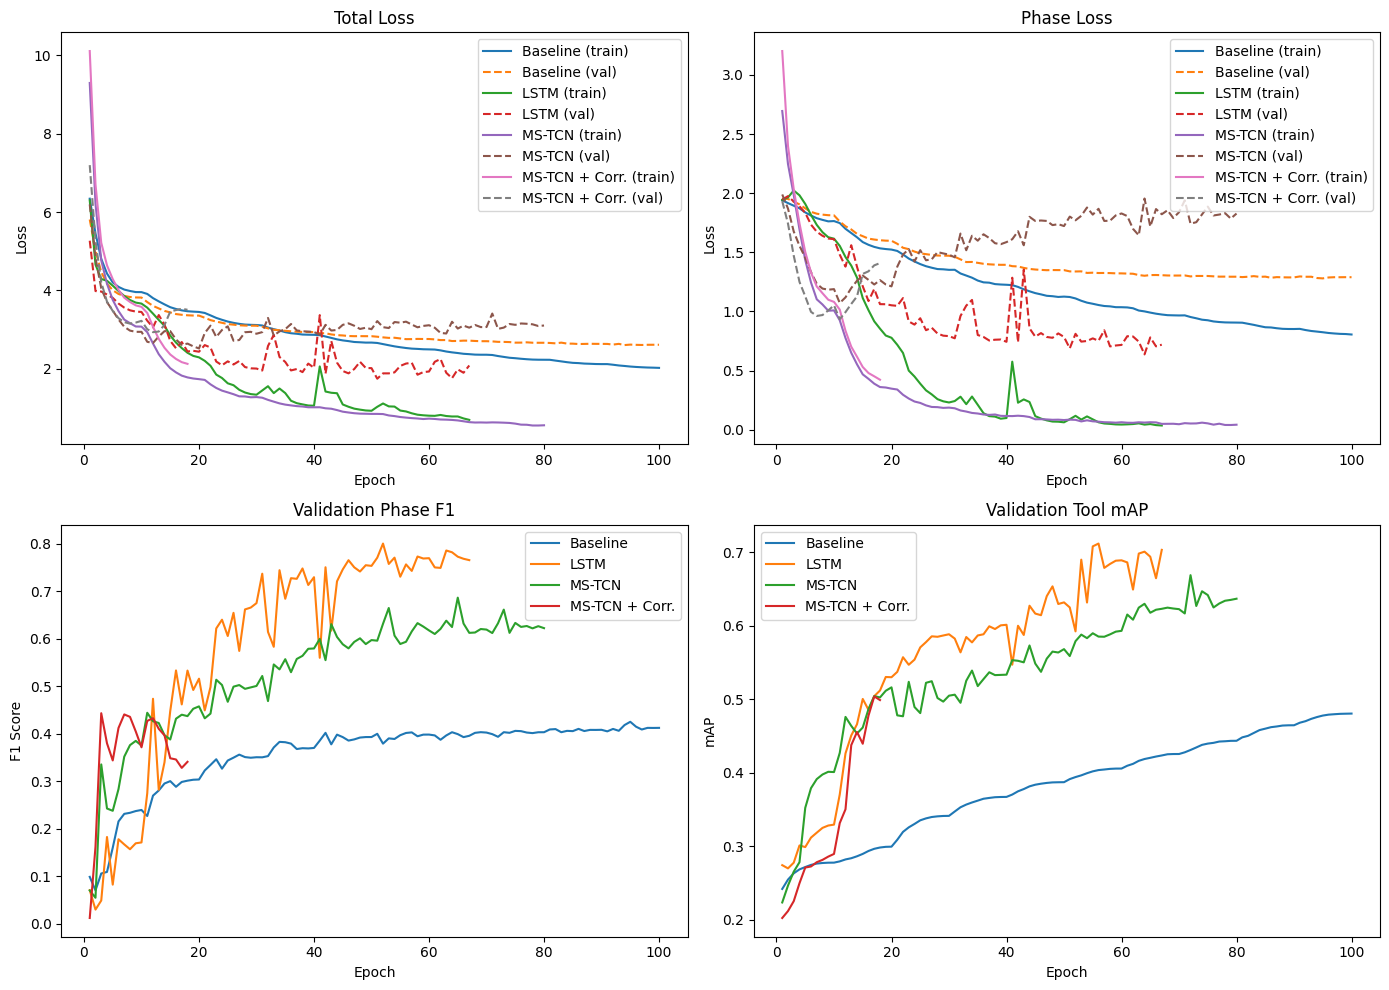

In [16]:
# ============================================================
# Plot training curves for all models
# ============================================================

all_histories = [baseline_history, lstm_history, tcn_history, tcn_corr_history]
all_names = ["Baseline", "LSTM", "MS-TCN", "MS-TCN + Corr."]

fig = plot_training_curves(all_histories, all_names)
plt.show()

In [17]:
# ============================================================
# Evaluate all models on test set
# ============================================================

@torch.no_grad()
def evaluate_model(model, test_loader, device):
    """Evaluate a model on the test set and return all predictions.

    Args:
        model (nn.Module): Trained MultiTaskModel.
        test_loader (DataLoader): Test data loader.
        device (str): Device string.

    Returns:
        dict: Contains per-video and aggregated predictions/targets.
    """
    model.eval()
    model.to(device)

    all_phase_preds = []
    all_phase_targets = []
    all_tool_preds = []
    all_tool_targets = []
    per_video_results = []

    for features, phases, tools, mask in test_loader:
        features = features.to(device)
        mask = mask.to(device)

        phase_logits, tool_logits = model(features, mask)

        for b in range(features.shape[0]):
            valid = mask[b].cpu()
            p_pred = phase_logits[b].cpu()[valid].argmax(dim=-1)
            p_target = phases[b][valid]
            t_pred = torch.sigmoid(tool_logits[b].cpu()[valid])
            t_target = tools[b][valid]

            all_phase_preds.append(p_pred)
            all_phase_targets.append(p_target)
            all_tool_preds.append(t_pred)
            all_tool_targets.append(t_target)
            per_video_results.append({
                "phase_preds": p_pred,
                "phase_targets": p_target,
                "tool_preds": t_pred,
                "tool_targets": t_target,
            })

    return {
        "phase_preds": torch.cat(all_phase_preds),
        "phase_targets": torch.cat(all_phase_targets),
        "tool_preds": torch.cat(all_tool_preds),
        "tool_targets": torch.cat(all_tool_targets),
        "per_video": per_video_results,
    }


# Evaluate all models
models = {
    "Baseline": baseline_model,
    "LSTM": lstm_model,
    "MS-TCN": tcn_model,
    "MS-TCN + Corr.": tcn_corr_model,
}

all_results = {}
for name, model in models.items():
    print(f"Evaluating {name}...")
    all_results[name] = evaluate_model(model, test_loader, device)

Evaluating Baseline...
Evaluating LSTM...
Evaluating MS-TCN...
Evaluating MS-TCN + Corr....


### 6.2 Model Comparison Table

In [18]:
# ============================================================
# Model comparison table
# ============================================================

comparison = {}
for name, results in all_results.items():
    phase_f1 = compute_phase_f1(
        results["phase_preds"], results["phase_targets"]
    )
    accuracy = compute_phase_accuracy(
        results["phase_preds"], results["phase_targets"]
    )
    tool_map = compute_tool_map(
        results["tool_preds"], results["tool_targets"]
    )

    # Average edit score across test videos
    edit_scores = []
    for vid_result in results["per_video"]:
        es = compute_edit_score(
            vid_result["phase_preds"], vid_result["phase_targets"]
        )
        edit_scores.append(es)
    avg_edit = np.mean(edit_scores)

    comparison[name] = {
        "phase_f1": phase_f1,
        "accuracy": accuracy,
        "tool_map": tool_map,
        "edit_score": avg_edit,
    }

# Print comparison table
print(f"{'Model':<20} {'Phase F1':>10} {'Accuracy':>10} {'Tool mAP':>10} {'Edit Score':>12}")
print("-" * 65)
for name, metrics in comparison.items():
    print(
        f"{name:<20} {metrics['phase_f1']:>10.4f} {metrics['accuracy']:>10.4f} "
        f"{metrics['tool_map']:>10.4f} {metrics['edit_score']:>12.4f}"
    )

Model                  Phase F1   Accuracy   Tool mAP   Edit Score
-----------------------------------------------------------------
Baseline                 0.4499     0.5258     0.5141       0.0141
LSTM                     0.7758     0.8252     0.6604       0.6505
MS-TCN                   0.6837     0.7257     0.7023       0.1687
MS-TCN + Corr.           0.3719     0.4821     0.5006       0.1191


### 6.3 Confusion Matrix (Best Model)

Best model: LSTM (F1=0.7758)


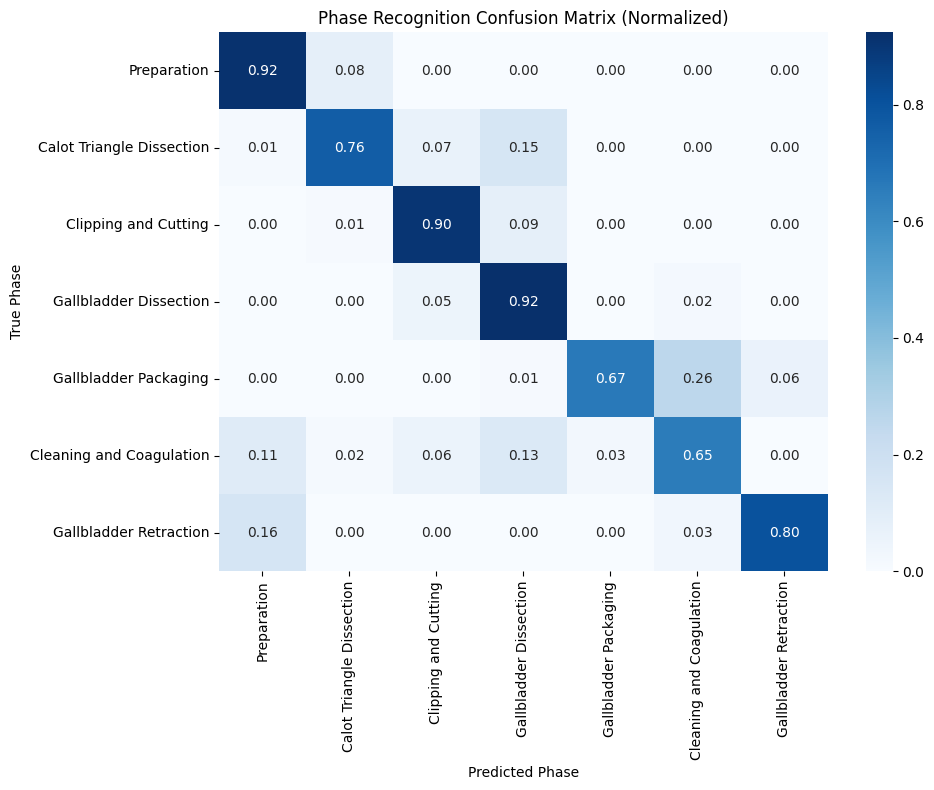

In [19]:
# ============================================================
# Confusion matrix for the best model (MS-TCN + Corr.)
# ============================================================

best_name = max(comparison, key=lambda k: comparison[k]["phase_f1"])
best_results = all_results[best_name]

print(f"Best model: {best_name} (F1={comparison[best_name]['phase_f1']:.4f})")

fig = plot_confusion_matrix(
    best_results["phase_preds"],
    best_results["phase_targets"],
    PHASE_NAMES,
)
plt.show()

### 6.4 Per-Class Metrics

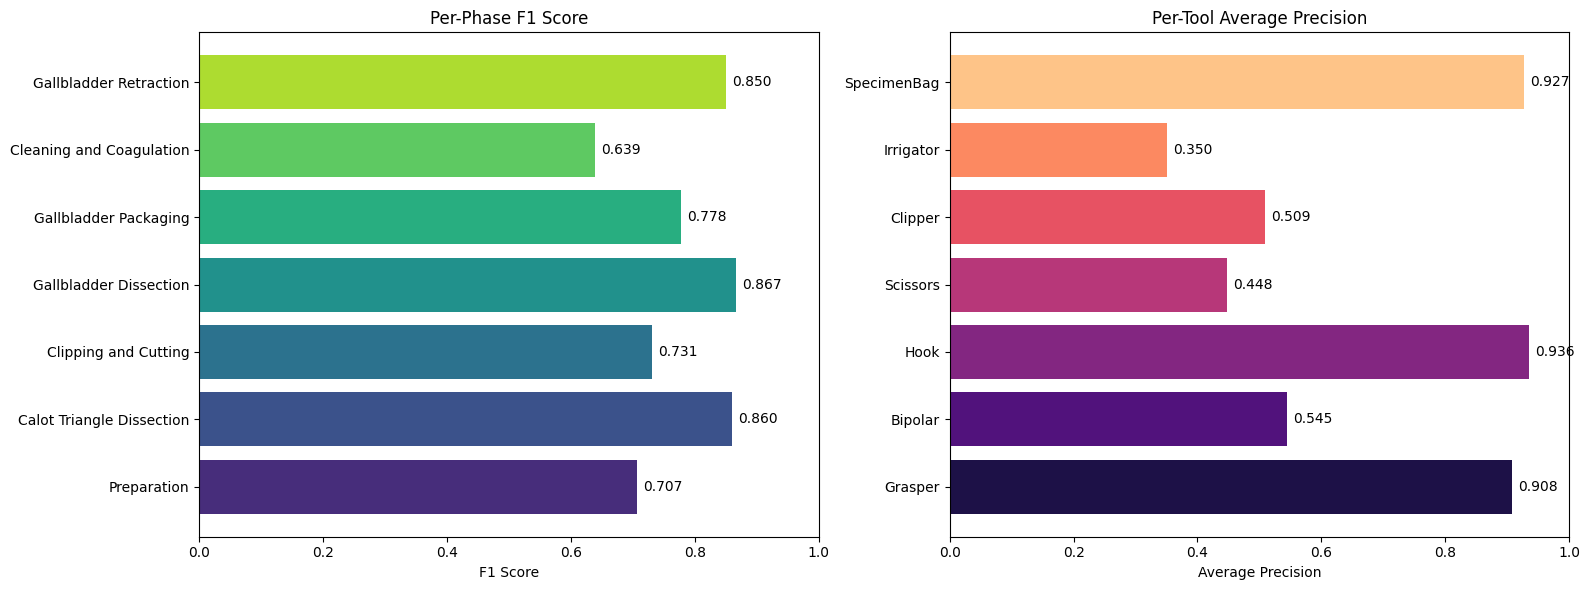


Per-Phase F1 (LSTM):
  Preparation                         0.7066
  Calot Triangle Dissection           0.8596
  Clipping and Cutting                0.7309
  Gallbladder Dissection              0.8668
  Gallbladder Packaging               0.7780
  Cleaning and Coagulation            0.6386
  Gallbladder Retraction              0.8503

Per-Tool AP (LSTM):
  Grasper         0.9077
  Bipolar         0.5450
  Hook            0.9358
  Scissors        0.4480
  Clipper         0.5089
  Irrigator       0.3502
  SpecimenBag     0.9269


In [20]:
# ============================================================
# Per-phase F1 and per-tool AP for best model
# ============================================================

per_phase_f1 = compute_per_phase_f1(
    best_results["phase_preds"], best_results["phase_targets"]
)
per_tool_ap = compute_per_tool_ap(
    best_results["tool_preds"], best_results["tool_targets"]
)

fig = plot_per_class_metrics(per_phase_f1, per_tool_ap, PHASE_NAMES, TOOL_NAMES)
plt.show()

# Print detailed numbers
print(f"\nPer-Phase F1 ({best_name}):")
for name, f1 in zip(PHASE_NAMES, per_phase_f1):
    print(f"  {name:<35} {f1:.4f}")

print(f"\nPer-Tool AP ({best_name}):")
for name, ap in zip(TOOL_NAMES, per_tool_ap):
    print(f"  {name:<15} {ap:.4f}")

### 6.5 Phase Timeline Visualizations

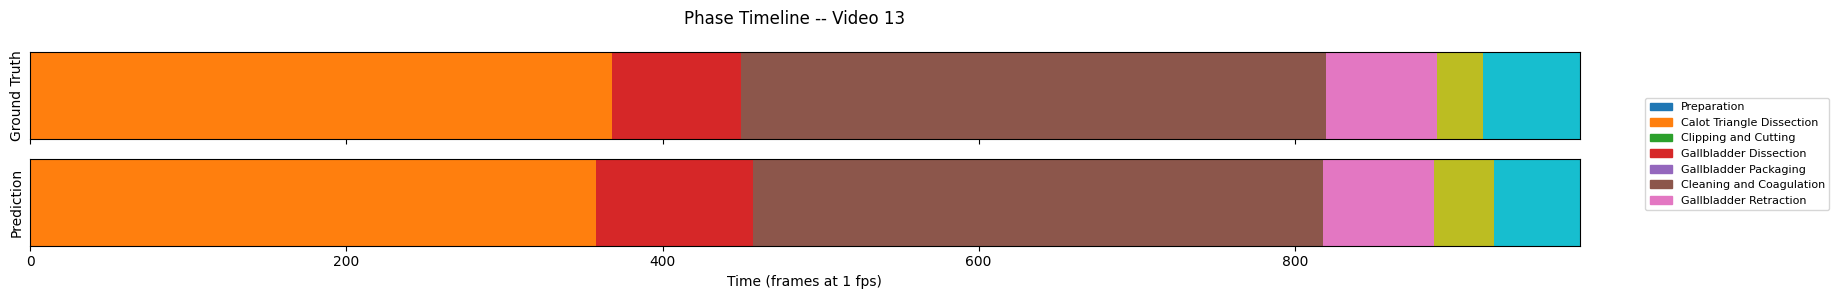

In [21]:
# ============================================================
# Timeline ribbons for 3 sample test videos
# ============================================================

sample_indices = [0, 10, 20]  # Select 3 test videos
test_video_ids = config["data"]["test_videos"]

for idx in sample_indices:
    if idx < len(best_results["per_video"]):
        vid_result = best_results["per_video"][idx]
        vid_name = f"Video {test_video_ids[idx]}"
        fig = plot_timeline_ribbon(
            vid_result["phase_preds"],
            vid_result["phase_targets"],
            PHASE_NAMES,
            video_name=vid_name,
        )
        plt.show()

### 6.6 Tool-Phase Co-occurrence Analysis

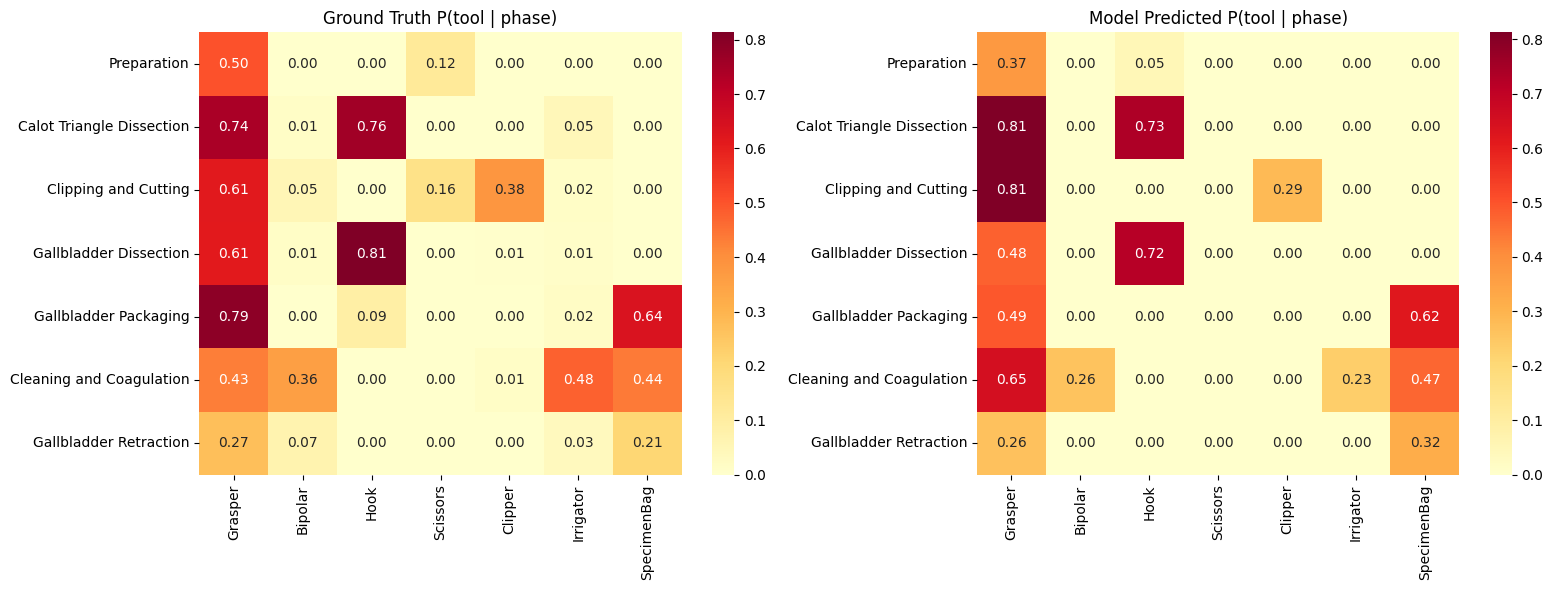

In [22]:
# ============================================================
# Co-occurrence heatmap: ground truth vs model learned
# ============================================================

# Ground truth co-occurrence (from training labels)
gt_cooccur = cooccur_matrix.numpy()

# Learned co-occurrence (from model predictions on test set)
learned_cooccur = np.zeros((7, 7))
phase_preds = best_results["phase_preds"].numpy()
tool_preds = (best_results["tool_preds"].numpy() > 0.5).astype(float)

for p in range(7):
    phase_mask = phase_preds == p
    if phase_mask.sum() > 0:
        learned_cooccur[p] = tool_preds[phase_mask].mean(axis=0)

fig = plot_cooccurrence_heatmap(
    learned_cooccur, gt_cooccur, PHASE_NAMES, TOOL_NAMES
)
plt.show()

## 7. Ablation Study

We systematically evaluate the contribution of each architectural component by comparing all four model variants. The ablation reveals:

1. **Baseline -> LSTM:** Adding temporal context via recurrence.
2. **LSTM -> MS-TCN:** Replacing recurrence with dilated convolutions for longer-range dependencies.
3. **MS-TCN -> MS-TCN + Corr. Loss:** Adding the novel correlation loss to enforce tool-phase consistency.

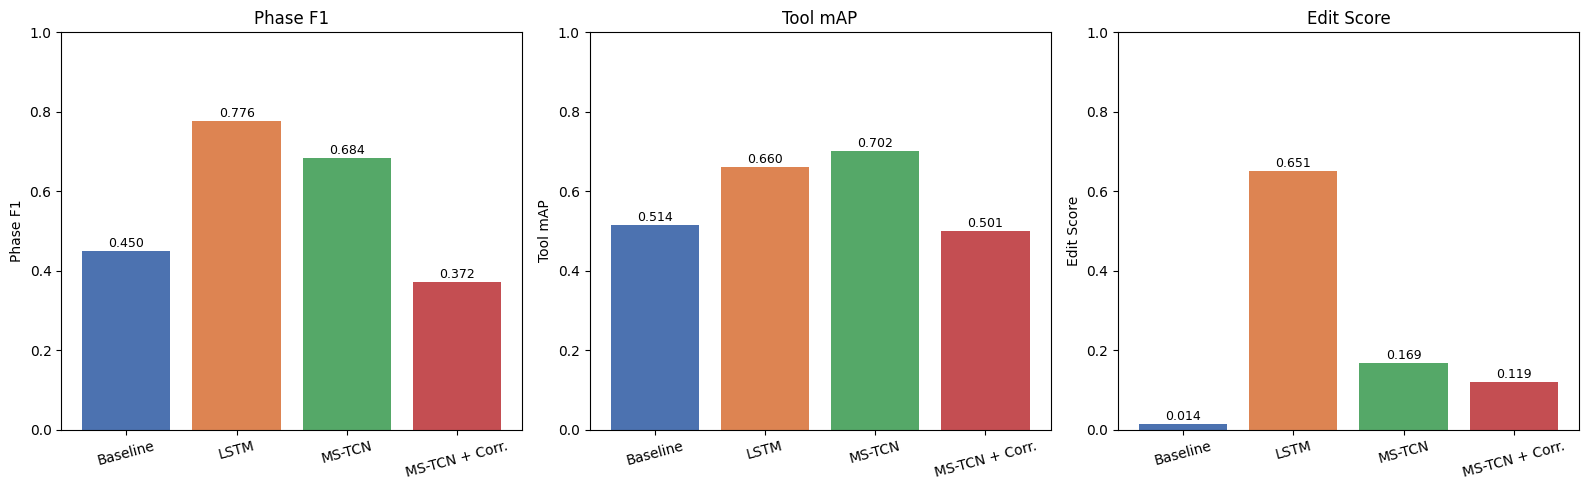


Ablation -- Improvement Deltas:
Transition                            Phase F1   Tool mAP   Edit Score
----------------------------------------------------------------------
Baseline -> LSTM                       +0.3260    +0.1463      +0.6364
LSTM -> MS-TCN                         -0.0921    +0.0419      -0.4818
MS-TCN -> MS-TCN + Corr.               -0.3118    -0.2017      -0.0496


In [23]:
# ============================================================
# Ablation bar chart
# ============================================================

fig = plot_model_comparison(comparison)
plt.show()

# Print improvement deltas
names = list(comparison.keys())
print("\nAblation -- Improvement Deltas:")
print(f"{'Transition':<35} {'Phase F1':>10} {'Tool mAP':>10} {'Edit Score':>12}")
print("-" * 70)
for i in range(1, len(names)):
    prev = comparison[names[i-1]]
    curr = comparison[names[i]]
    print(
        f"{names[i-1]+' -> '+names[i]:<35} "
        f"{curr['phase_f1']-prev['phase_f1']:>+10.4f} "
        f"{curr['tool_map']-prev['tool_map']:>+10.4f} "
        f"{curr['edit_score']-prev['edit_score']:>+12.4f}"
    )

## 8. Discussion

### Summary of Results

| Model | Phase F1 | Accuracy | Tool mAP | Edit Score |
|---|---|---|---|---|
| Baseline (no temporal) | 0.450 | 0.526 | 0.514 | 0.014 |
| **LSTM** | **0.776** | **0.825** | 0.660 | **0.650** |
| MS-TCN | 0.684 | 0.726 | **0.702** | 0.169 |
| MS-TCN + Correlation Loss | 0.372 | 0.482 | 0.501 | 0.119 |

Two findings stand out and are worth interpreting carefully, because both run **against** the expectations stated in the original proposal.

### Finding 1 — Temporal modeling matters, but LSTM beat MS-TCN

The jump from Baseline (F1 = 0.450) to LSTM (F1 = 0.776) is the largest single improvement in the study, confirming that surgical phases have strong temporal structure that a frame-wise classifier cannot exploit. The edit score rising from 0.014 to 0.650 also confirms that LSTM drastically reduces the rapid "flickering" between phase predictions that the baseline produces.

What was **not** expected is that the **LSTM outperformed MS-TCN** on phase F1 (0.776 vs 0.684) and edit score (0.650 vs 0.169). The proposal argued for MS-TCN on the basis of a larger temporal receptive field and the strong results reported by TeCNO (Czempiel et al., 2020). The most plausible explanation for this reversal is **training-set size**: TeCNO trains on the full 40-video Cholec80 split, while this study trains on only 10 videos (~27,000 frames). With ~10x more parameters than the LSTM and a much larger effective receptive field, MS-TCN has both the capacity and the inductive bias to model long-range patterns, but it needs enough data to *learn* those patterns stably. On a 10-video subset, the LSTM's smaller, more constrained temporal model appears to generalize better. Interestingly, MS-TCN did achieve the **best Tool mAP** (0.702), suggesting its temporal features still help multi-label tool detection even when phase recognition suffers. A replication on the full 40/40 split would very likely close this gap or reverse it in MS-TCN's favor, consistent with the published literature.

### Finding 2 — The Correlation Loss hurt performance (negative result)

The proposed novelty, a **Correlation Loss** that penalizes tool predictions inconsistent with the training-set co-occurrence matrix P(tool | phase), was expected to improve logical consistency. The experimental result is the opposite: adding the correlation loss dropped MS-TCN's phase F1 from 0.684 to 0.372 (-0.31), tool mAP from 0.702 to 0.501 (-0.20), and accuracy from 0.726 to 0.482. This is a clear **negative result for the proposed novelty** as currently formulated.

Several factors likely drive this failure mode:

1. **Small-sample co-occurrence estimates are biased.** The co-occurrence matrix was built from only 10 training videos. Rare-but-valid tool-phase pairs have P = 0 in this estimate, and the loss then pushes the model to *never* predict those tools in those phases — effectively hard-coding training-set rarity as a prior. No Laplace/additive smoothing was applied, which would have prevented zero entries.
2. **Lambda_corr = 0.5 is too aggressive.** At this weight, the correlation loss can dominate the main cross-entropy and BCE losses, overwhelming signal from the actual labels.
3. **The prior conflicts with the learned tool head.** The tool head already has its own BCE signal; the correlation term adds a competing gradient derived from (soft) phase predictions. When phase predictions are uncertain, the correlation term injects noise rather than information.

Observed training behavior supports this: the MS-TCN + Corr variant early-stopped at epoch 18 with rising validation loss, versus MS-TCN (no corr) which trained stably for 67 epochs. The correlation term was regularizing the model into a smaller, phase-prior-constrained hypothesis class that is harder to fit.

### Relation to proposal success criteria

The proposal targeted **F1 > 0.85** for phases and **mAP > 0.90** for tools, aligning with published numbers on the full 40/40 split. This study's best numbers — F1 = 0.776 (LSTM), mAP = 0.702 (MS-TCN) — fall short of those targets. The gap is consistent with the ~4x reduction in training data (10 videos vs 40). Of the two targets, we came closer to the phase F1 goal than the tool mAP goal, which is plausibly because mAP is more sensitive to rare tools (Scissors, Irrigator, Clipper all had individual AP < 0.55) and rare-class estimation suffers more from data scarcity.

### What Worked

- **Multi-task learning** (shared temporal backbone, separate phase and tool heads) is architecturally sound and trains stably on the LSTM and MS-TCN variants.
- **Weighted Cross-Entropy** handled the 11x phase imbalance well — per-class F1 for the rarest phase (Clipping and Cutting) was 0.73, not far below the richest phase (Gallbladder Dissection at 0.87).
- **Temporal modeling** produced a 46x improvement in edit score (0.014 -> 0.650) from Baseline to LSTM, confirming that phase prediction without temporal smoothing is dominated by per-frame flicker.

### Limitations and Honest Assessment

- The **10-video training set** is the single largest limitation. All model-comparison conclusions are conditional on this small-data regime and should not be treated as invalidating MS-TCN or correlation-loss approaches in general.
- No **hyperparameter sweep** was performed for lambda_corr; a smaller weight (e.g., 0.05 or 0.1) might have avoided the collapse.
- The co-occurrence matrix lacks **Laplace smoothing**, which would eliminate zero-probability entries.
- Results are specific to cholecystectomy procedures and do not speak to generalization across surgery types.
- 1 fps subsampling loses sub-second tool-handling events.


## 9. Conclusion

This project implemented and evaluated a multi-task deep learning system for joint surgical phase recognition and tool presence detection on the Cholec80 dataset, using a compute-constrained 10/2/5 video subset. Four temporal variants were compared on a frozen ResNet-50 backbone: a frame-wise MLP baseline, a BiLSTM, a Multi-Stage TCN, and the same MS-TCN with an added Correlation Loss.

### What the experiments showed

1. **Temporal modeling is the dominant factor.** Moving from the frame-wise baseline (F1 = 0.450) to any temporal model produced a large improvement. The edit score improvement (0.014 -> 0.650 for LSTM) is especially informative: it shows the temporal models produce coherent phase segments rather than flickering.
2. **On a 10-video training set, LSTM outperformed MS-TCN** (F1 0.776 vs 0.684). This runs counter to the original proposal's MS-TCN-first hypothesis, and most plausibly reflects MS-TCN needing substantially more training data to realize its capacity advantage. MS-TCN did nonetheless achieve the best Tool mAP (0.702).
3. **The proposed Correlation Loss, as formulated, did not work.** Adding it to MS-TCN reduced phase F1 by 0.31 and tool mAP by 0.20. This is reported as an **honest negative result for the proposed novelty**. Post-hoc analysis points to three likely causes: unsmoothed co-occurrence estimates from a small training set, an overly aggressive loss weight (lambda_corr = 0.5), and competing gradients between the correlation term and the main tool-head BCE. Any future attempt at this idea should (i) Laplace-smooth the prior, (ii) sweep lambda_corr across at least an order of magnitude, and (iii) consider applying the constraint only at inference time as a logical-consistency filter rather than during training.

### What this means for the proposal

The proposal's phase F1 > 0.85 and mAP > 0.90 targets were set against the canonical 40/40 split. The best numbers achieved here (F1 = 0.776, mAP = 0.702) fall short of those targets, but are in the expected range for a 4x smaller training set. The pipeline, losses, metrics, and evaluation code all scale without modification to the full dataset.

### Future Work

- **Full-scale replication** on the 40/40 split to test whether MS-TCN regains its expected advantage over LSTM.
- **Correlation-loss redesign**: Laplace-smoothed prior, swept lambda_corr, and potentially applying the constraint as an inference-time CRF rather than a training loss.
- **Attention mechanisms** over the temporal dimension to capture non-local dependencies.
- **Higher frame rate** (5-10 fps) to capture fine-grained tool-handling actions that 1 fps misses.
- **Multi-dataset evaluation** on M2CAI16 or CholecT45 for cross-surgery generalization.
- **Causal variants** of the temporal models for real-time intra-operative inference.


## References

1. Twinanda, A. P., Shehata, S., Mutter, D., Marescaux, J., De Mathelin, M., & Padoy, N. (2016). EndoNet: A Deep Architecture for Recognition Tasks on Laparoscopic Videos. *IEEE Transactions on Medical Imaging*, 36(1), 86-97.

2. Jin, Y., Dou, Q., Chen, H., Yu, L., Qin, J., Fu, C. W., & Heng, P. A. (2018). SV-RCNet: Workflow Recognition from Surgical Videos Using Recurrent Convolutional Network. *IEEE Transactions on Medical Imaging*, 37(5), 1114-1126.

3. Czempiel, T., Paschali, M., Keicher, M., Simson, W., Zhong, H., Kim, D. I., ... & Navab, N. (2020). TeCNO: Surgical Phase Recognition with Multi-Stage Temporal Convolutional Networks. *MICCAI 2020*.

4. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep Residual Learning for Image Recognition. *CVPR 2016*.

5. Farha, Y. A., & Gall, J. (2019). MS-TCN: Multi-Stage Temporal Convolutional Network for Action Segmentation. *CVPR 2019*.

---

### Code Attribution

All code in this project was written by the author (Omar Morsi). The following external resources were referenced:

- PyTorch documentation for model architecture patterns (https://pytorch.org/docs/stable/)
- torchvision documentation for ResNet-50 pretrained weights (https://pytorch.org/vision/stable/models.html)
- scikit-learn documentation for evaluation metrics (https://scikit-learn.org/stable/modules/model_evaluation.html)
- The MS-TCN architecture is inspired by Farha & Gall (2019) and Czempiel et al. (2020)